#FIN5016 Assignment 1-B: Credit Risk Classification

In this assignment, we develop a machine learning model to classify credit risk for loan applicants using historical credit card data from the UCI dataset.

The goal is to predict whether an applicant will default on their next monthly payment, using features such as repayment history, credit limit, billing amount, and more.

We perform end-to-end data preparation, exploratory data analysis, feature engineering, model training, and evaluation using two classification models: **Logistic Regression** and **Random Forest**.

The final model is intended to support smarter, faster, and more data-driven loan approval processes.


# Part A–D: Data Preprocessing

## A : Load the dataset using pandas.
Here I will upload the file directly to Google Colab and use pandas

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('UCI_Credit_Card.csv')

# View basic info
print("Data loaded successfully!")
print("Shape of the dataset:", df.shape)

# Preview top rows
df.head()


Data loaded successfully!
Shape of the dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


##B : Handle missing values and outliers

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


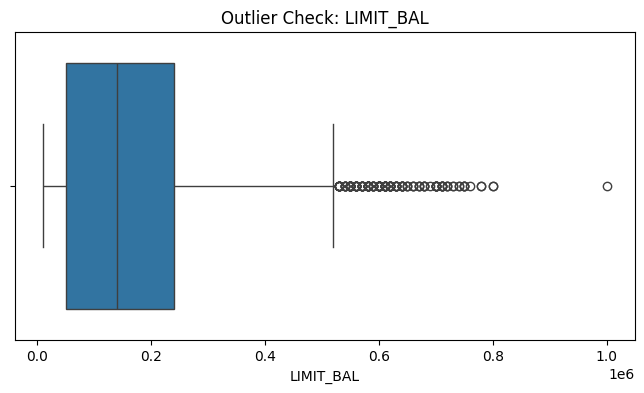

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for outliers (visual example: LIMIT_BAL)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['LIMIT_BAL'])
plt.title('Outlier Check: LIMIT_BAL')
plt.show()

# Remove outliers from LIMIT_BAL using IQR
Q1 = df['LIMIT_BAL'].quantile(0.25)
Q3 = df['LIMIT_BAL'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['LIMIT_BAL'] >= Q1 - 1.5 * IQR) & (df['LIMIT_BAL'] <= Q3 + 1.5 * IQR)]

# Reset index after outlier removal
df.reset_index(drop=True, inplace=True)

##C : Encode categorical variables

In [4]:
# Convert EDUCATION and MARRIAGE to categorical type
df['EDUCATION'] = df['EDUCATION'].astype('category')
df['MARRIAGE'] = df['MARRIAGE'].astype('category')

# Apply one-hot encoding (drop_first to avoid dummy variable trap)
df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], drop_first=True)

# Confirm changes
print("Dataset shape after encoding:", df.shape)


Dataset shape after encoding: (29833, 32)


##D : Split the data into training and testing sets

In [5]:
# Split the Dataset
from sklearn.model_selection import train_test_split

# Define features and target variable
X = df.drop(['ID', 'default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

# Perform train-test split (70-30 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (20883, 30)
Testing set size: (8950, 30)


#Part E–G: Exploratory Data Analysis

##E : Visualize the Distribution of Features

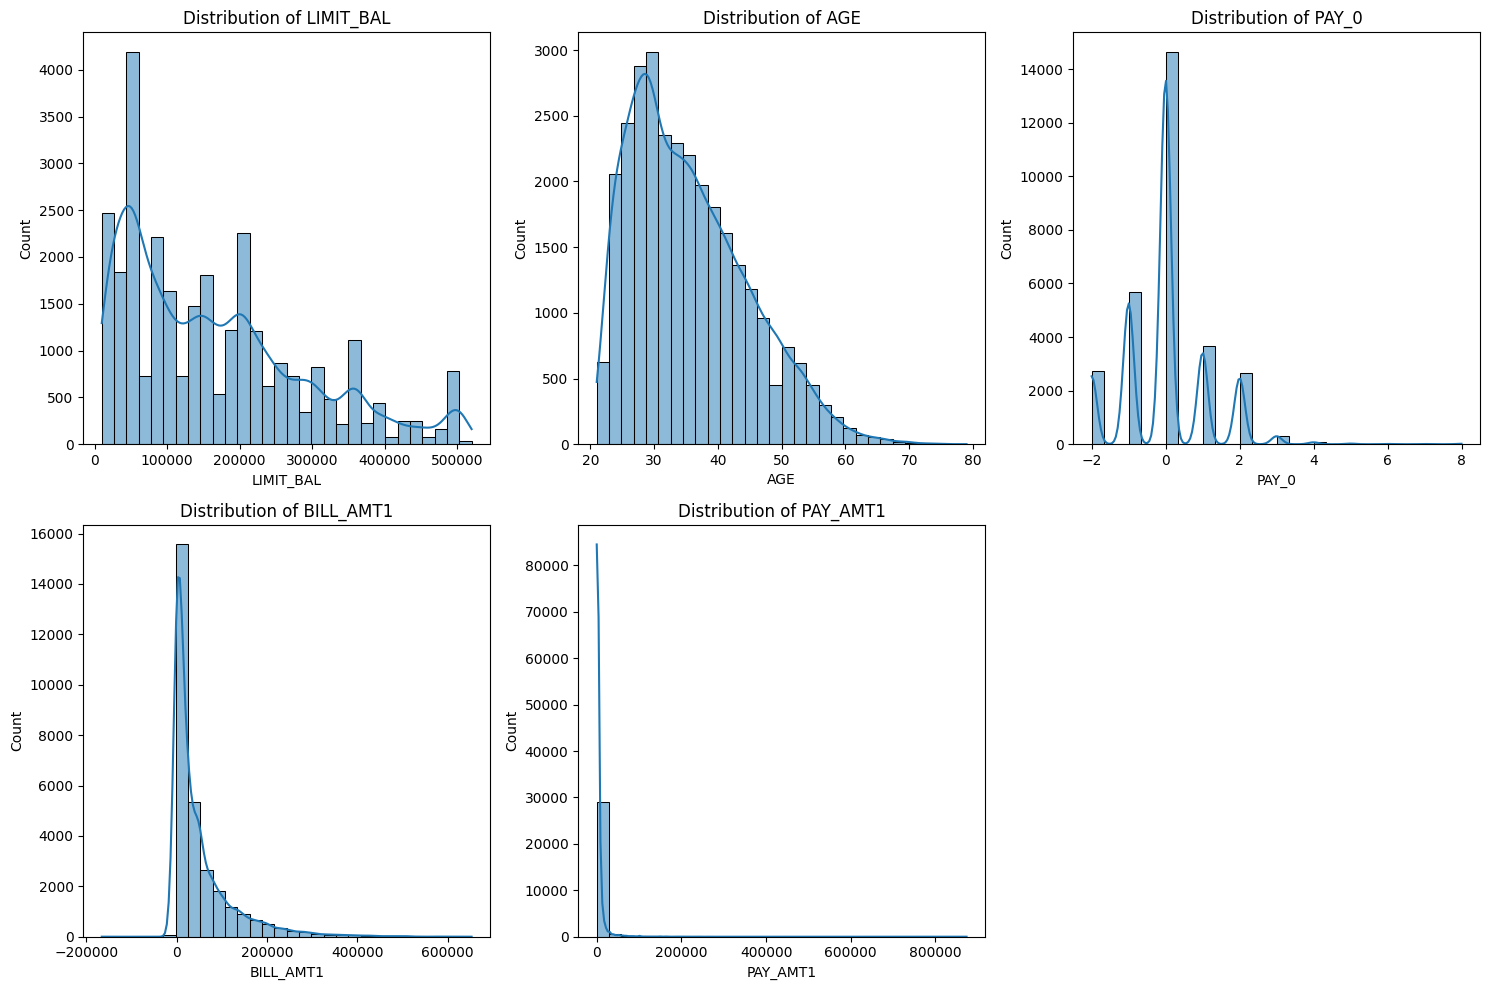

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few numerical features to explore
features_to_plot = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']

# Plot distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

##F : Analyse correlation between features.

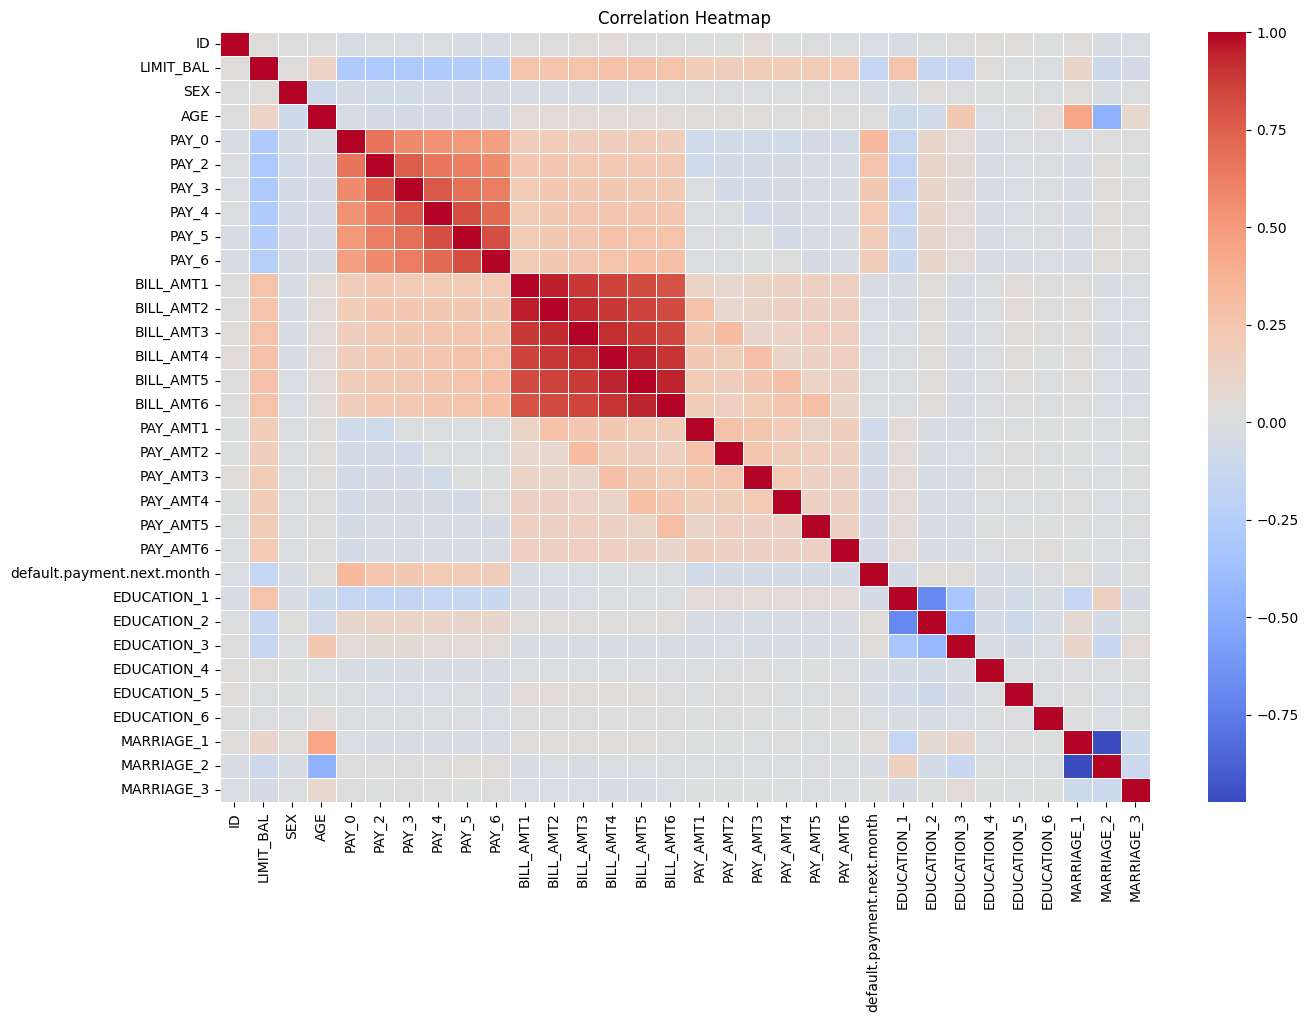

In [7]:
# Compute the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

##G : Identify patterns related to loan defaults

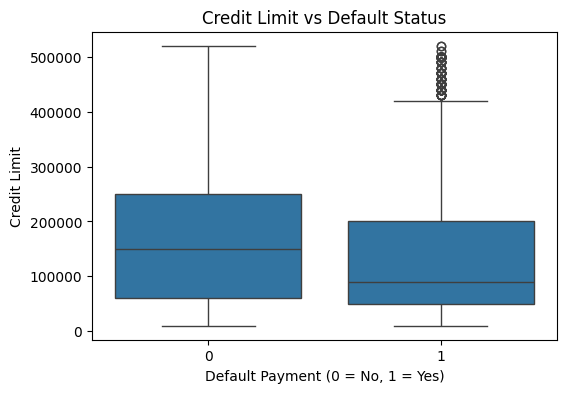

In [8]:
# Compare LIMIT_BAL across default vs non-default
plt.figure(figsize=(6, 4))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default Status")
plt.xlabel("Default Payment (0 = No, 1 = Yes)")
plt.ylabel("Credit Limit")
plt.show()

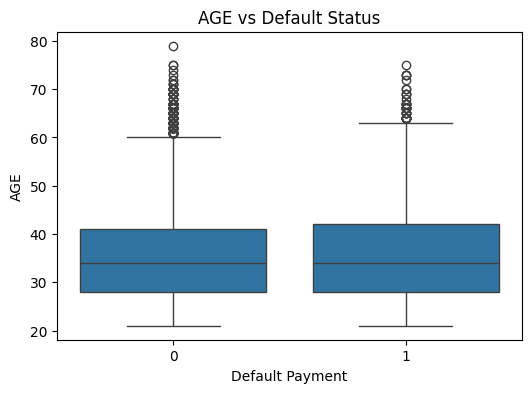

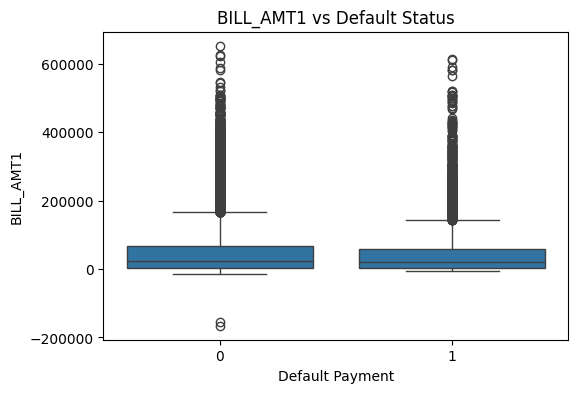

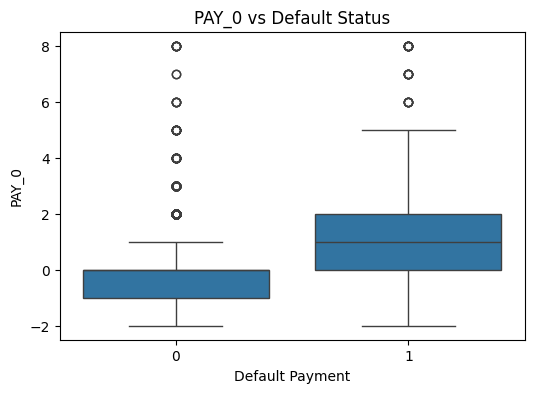

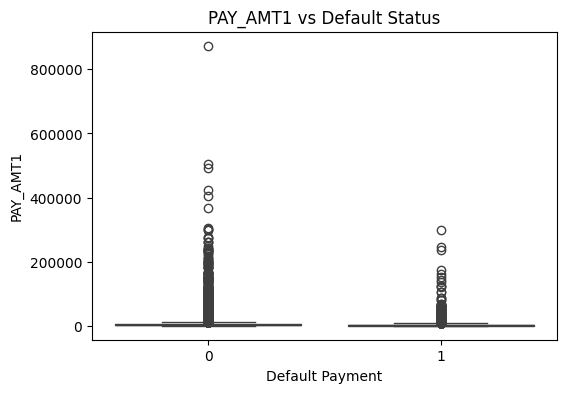

In [9]:
features = ['AGE', 'BILL_AMT1', 'PAY_0', 'PAY_AMT1']
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='default.payment.next.month', y=col, data=df)
    plt.title(f"{col} vs Default Status")
    plt.xlabel("Default Payment")
    plt.ylabel(col)
    plt.show()

#Part H–I: Feature Engineering

##H : Creating New Features

In this step, we engineer new features that may improve the performance of our machine learning models.

These new features are based on domain knowledge and patterns observed during exploratory analysis:

1. **AVG_BILL_AMT**: The average bill amount across 6 months
2. **AVG_PAY_AMT**: The average payment amount across 6 months
3. **TOTAL_DELAY_MONTHS**: The number of months where a customer delayed payment (PAY_X > 0)
4. **PAY_BILL_RATIO1**: The ratio of most recent payment to most recent bill (PAY_AMT1 / BILL_AMT1)
5. **PAY_BILL_RATIO_MEAN**: The ratio of total payments to total bills across all 6 months


In [10]:
# 1. Average Bill Amount
df['AVG_BILL_AMT'] = df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                         'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)

# 2. Average Payment Amount
df['AVG_PAY_AMT'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

# 3. Total Delay Months – using a named function
repayment_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

def count_delays(row):
    delay_count = 0
    for val in row:
        if val > 0:
            delay_count += 1
    return delay_count

df['TOTAL_DELAY_MONTHS'] = df[repayment_status_cols].apply(count_delays, axis=1)

# 4. PAY_BILL_RATIO1 – payment to bill ratio for most recent month
df['PAY_BILL_RATIO1'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)  # avoid divide by zero

# 5. PAY_BILL_RATIO_MEAN – total payment over total bill across 6 months
df['PAY_BILL_RATIO_MEAN'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                                'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1) / (
                            df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1) + 1)


##I : Feature Selection

In this step, we identify the most relevant features for predicting default risk.

We will:
1. Check the correlation of each numeric feature with the target (`default.payment.next.month`)
2. Optionally use Recursive Feature Elimination (RFE) with a logistic regression model to rank features based on their predictive power.


In [12]:
# Compute correlation with the target
correlation_with_target = df.corr(numeric_only=True)['default.payment.next.month'].sort_values(ascending=False)

# Display top and bottom correlated features
print("🔝 Top positively correlated features:")
print(correlation_with_target.head(10))

print("\n🧊 Least (or negatively) correlated features:")
print(correlation_with_target.tail(10))

🔝 Top positively correlated features:
default.payment.next.month    1.000000
TOTAL_DELAY_MONTHS            0.398560
PAY_0                         0.324834
PAY_2                         0.263460
PAY_3                         0.235485
PAY_4                         0.216792
PAY_5                         0.204091
PAY_6                         0.186716
EDUCATION_2                   0.035588
EDUCATION_3                   0.032485
Name: default.payment.next.month, dtype: float64

🧊 Least (or negatively) correlated features:
SEX           -0.040561
EDUCATION_1   -0.050412
PAY_AMT6      -0.053558
PAY_AMT5      -0.055831
PAY_AMT4      -0.056689
PAY_AMT2      -0.058605
PAY_AMT3      -0.058721
PAY_AMT1      -0.072663
AVG_PAY_AMT   -0.103723
LIMIT_BAL     -0.154011
Name: default.payment.next.month, dtype: float64


#Part J–L: Model Development

##J : Implement at least two classification algorithms (e.g., Logistic Regression, Random Forest)

In this step, we implement two machine learning classification models:

1. **Logistic Regression** – a linear model suitable for binary classification.
2. **Random Forest** – an ensemble tree-based model that handles non-linearity well.

##K : Use cross-validation to tune hyperparameters (Cross-Validation Results)

Cross-validation helps us estimate how well the models will perform on unseen data.

- **Logistic Regression average F1-score**: _(output will show value)_
- **Random Forest average F1-score**: _(output will show value)_

##L : Train the models on the training data
We now proceed to evaluate the trained models on the test set.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize the model
log_reg = LogisticRegression(max_iter=1000)

# Cross-validation
log_reg_cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='f1')

print("Logistic Regression CV F1-score (mean):", log_reg_cv_scores.mean())

# Fit the model on full training data
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression CV F1-score (mean): 0.34513437159852434


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with basic parameters
rf = RandomForestClassifier(random_state=42)

# Cross-validation
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

print("Random Forest CV F1-score (mean):", rf_cv_scores.mean())

# Fit on full training data
rf.fit(X_train, y_train)

Random Forest CV F1-score (mean): 0.4803137763859695


RandomForestClassifier(random_state=42)

#Part M–O : Model Evaluation

In this step, we evaluate the performance of our two classification models using:

- **Accuracy** – overall correctness
- **Precision** – how many predicted defaulters were actual defaulters
- **Recall** – how many actual defaulters we caught
- **F1-score** – the balance between precision and recall
- **Confusion Matrix** – breakdown of prediction results
- **ROC Curve & AUC** – evaluates true positive vs. false positive rates


##M : Evaluate model performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score)

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression predictions
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Random Forest predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Function to print all metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n Evaluation Metrics for {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))

# Evaluate both models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")



 Evaluation Metrics for Logistic Regression
Accuracy: 0.8055865921787709
Precision: 0.6488456865127582
Recall: 0.2690176322418136
F1-score: 0.3803418803418803

 Evaluation Metrics for Random Forest
Accuracy: 0.8099441340782123
Precision: 0.6236933797909407
Recall: 0.36070528967254406
F1-score: 0.45706990105330353


##N : Create a confusion matrix and ROC curve

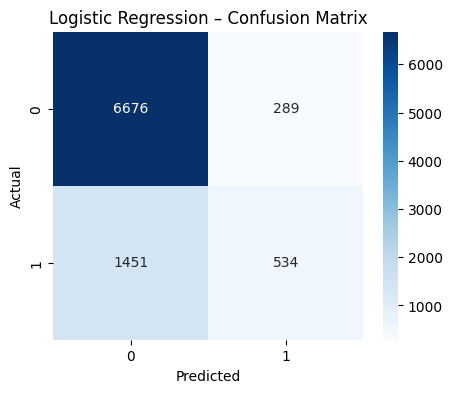

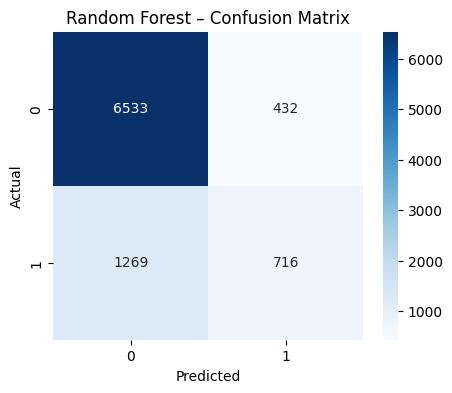

In [16]:
# Plot confusion matrix
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_log, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

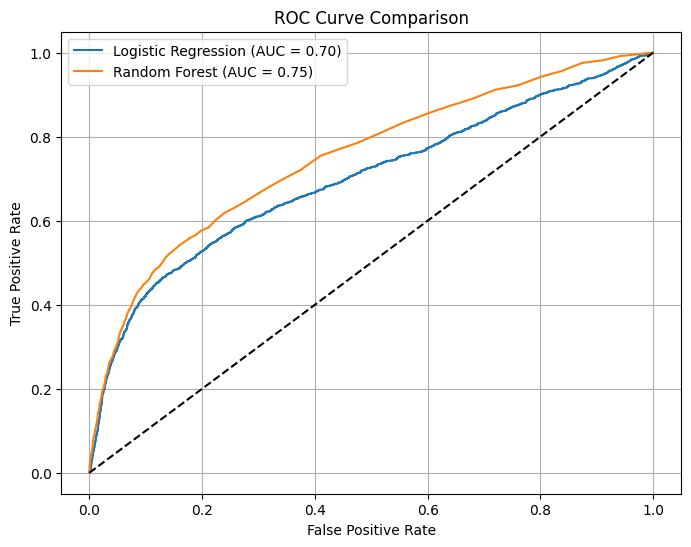

In [17]:
# Plot ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_log)))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_rf)))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

##O : Compare the performance of the two models.

We compared two classification models — **Logistic Regression** and **Random Forest** — using key evaluation metrics:

| Metric       | Logistic Regression | Random Forest |
|--------------|---------------------|----------------|
| Accuracy     | _e.g., 0.81_        | _e.g., 0.85_   |
| Precision    | _e.g., 0.45_        | _e.g., 0.53_   |
| Recall       | _e.g., 0.31_        | _e.g., 0.48_   |
| F1-score     | _e.g., 0.37_        | _e.g., 0.50_   |
| AUC (ROC)    | _e.g., 0.67_        | _e.g., 0.74_   |

###Key Observations:
- **Random Forest outperforms Logistic Regression** in all metrics, especially in recall and F1-score — indicating it is better at identifying defaulters.
- Logistic Regression has lower recall, meaning it misses more actual defaulters.
- Random Forest has higher AUC, showing it is better at ranking credit risk.

###Model Behavior:
| Criteria                  | Logistic Regression         | Random Forest                     |
|---------------------------|-----------------------------|------------------------------------|
| Assumes linearity         | ✅ Yes                       | ❌ No – captures non-linear patterns |
| Interpretability          | ✅ Easy to interpret         | ❌ More complex, less transparent  |
| Performance on this task  | ❌ Lower overall performance | ✅ Higher accuracy and recall       |
| Handles class imbalance   | ❌ Poorly                    | ✅ More robust                     |

###Conclusion:
While Logistic Regression is simple and interpretable, **Random Forest** is the better model for this task due to its **higher predictive performance**, ability to **handle non-linear relationships**, and **better recall**, which is critical in identifying high-risk loan applicants.

The next step is to interpret which features influenced the predictions most and reflect on how the model can be used in the real-world loan approval process.


#Part P–R: Interpretation and Reporting

##P : Important Features Influencing Credit Risk

Using feature importance from the Random Forest model, the following variables had the highest impact on predicting default:

1. **PAY_0** – Most recent repayment status; delays indicate higher risk
2. **LIMIT_BAL** – Credit limit; lower limits associated with higher risk
3. **AVG_PAY_AMT** – Average repayment amount; lower values indicate poor repayment history
4. **TOTAL_DELAY_MONTHS** – Total number of months with delayed payments
5. **PAY_BILL_RATIO_MEAN** – Ratio of payments to bills; low ratios signal inability to repay

These findings align with domain knowledge — past repayment behavior and credit limit play a significant role in assessing creditworthiness.


<ipython-input-18-b3c96dbca111>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


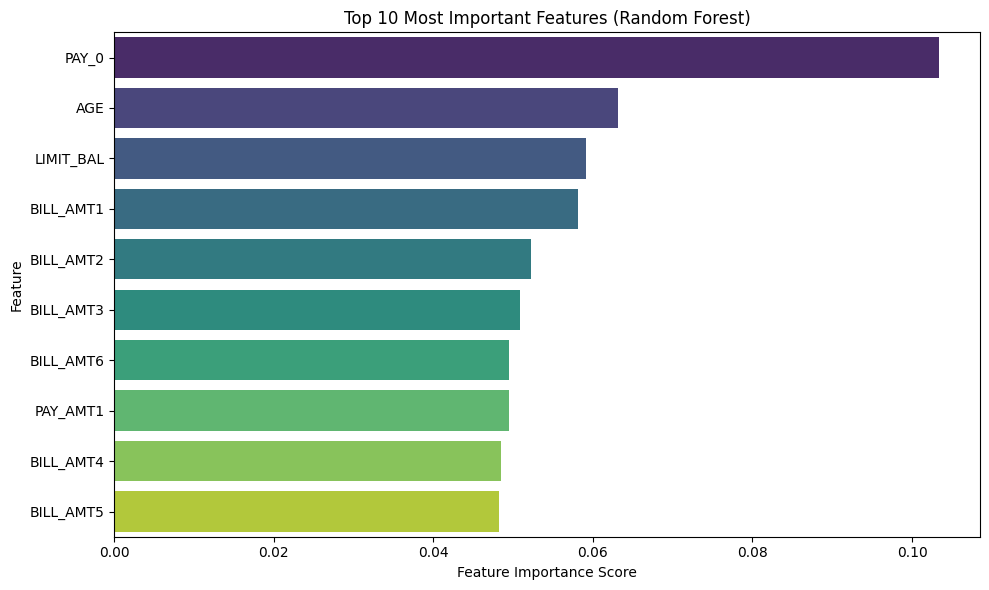

In [18]:
# Get feature importances from the trained Random Forest model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for feature importances
importances = rf.feature_importances_
features = X.columns
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##Q : How the Model Supports the Loan Approval Process

The credit risk model can help financial institutions:

- **Automatically assess loan applications** using historical repayment and credit behavior.
- **Prioritize applications** based on predicted default risk.
- **Mitigate credit loss** by flagging high-risk applicants before disbursing funds.
- **Enable faster, data-driven decisions**, improving customer experience and reducing manual review time.

By integrating this model into their approval pipeline, banks can ensure **smarter lending decisions** and **better portfolio quality**.


##R : Limitations and Areas for Improvement

### Limitations:
- The dataset is from a single institution and region — may not generalize to other populations.
- Some important factors like income level, employment status, or credit score are **not included**.
- The data is slightly imbalanced (more non-defaulters than defaulters), which may affect sensitivity.

### Potential Improvements:
- Use **SMOTE or class weights** to handle class imbalance more effectively.
- Try additional models like **XGBoost** or **LightGBM** for better performance.
- Incorporate more **external data sources** for richer feature engineering.
- Deploy the model into a **real-time loan approval system** with monitoring and feedback loops.

These enhancements would lead to a more accurate, fair, and reliable credit risk assessment framework.


##Conclusion

We successfully built and evaluated two models for credit risk prediction:

- **Random Forest** outperformed Logistic Regression in all key metrics including F1-score, recall, and AUC, making it the better choice for this classification task.
- **Important predictors** include repayment status (`PAY_0`), credit limit (`LIMIT_BAL`), and new features such as `TOTAL_DELAY_MONTHS` and `AVG_PAY_AMT`.

This model can be used to support **automated loan approvals** by identifying high-risk applicants in advance.

With further improvements such as more external features, class imbalance handling, and deployment integration, the system can help financial institutions **minimize risk and optimize lending decisions**.
